In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import gaussian_kde
from scipy.interpolate import UnivariateSpline

In [2]:
# Data Loading
# ---------------------------------------

def load_lammps_log(filename):
    T, V = [], []

    with open(filename, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if "Step" in line and "Temp" in line:
            headers = line.split()
            start = i + 1
            break

    temp_idx = headers.index("Temp")
    vol_idx = headers.index("Volume")

    for line in lines[start:]:
        parts = line.split()
        if len(parts) != len(headers):
            continue
        try:
            T.append(float(parts[temp_idx]))
            V.append(float(parts[vol_idx]))
        except:
            continue

    return np.array(T), np.array(V)


In [3]:
# Mask-Based Preprocess 
# ---------------------------------------

def preprocess(T, V, min_T=300, max_T=600, step=1):
    mask = (T >= min_T) & (T <= max_T)
    T, V = T[mask], V[mask]

    idx = np.argsort(T)
    T, V = T[idx], V[idx]

    T = T[::step]
    V = V[::step]

    return T, V

In [4]:
# Normalization
# ---------------------------------------

def normalize(T, V):
    Tm, Ts = np.mean(T), np.std(T)
    Vm, Vs = np.mean(V), np.std(V)
    return (T - Tm)/Ts, (V - Vm)/Vs, (Tm, Ts, Vm, Vs)


def denorm_T(Tn, norm):
    Tm, Ts, _, _ = norm
    return Tn * Ts + Tm
    

In [5]:
# Piecewise-Linear Approximation & Huber Function 
# ---------------------------------------
    
def pw_model(T, p):
    Tg, a0, a1, b1 = p
    Vg = a0 + a1 * Tg
    return np.where(T < Tg, a0 + a1*T, Vg + b1*(T - Tg))


def huber(r, d=1.0):
    a = np.abs(r)
    return np.where(a < d, 0.5*r**2, d*(a - 0.5*d))


def pw_loss(p, T, V):
    Tg, a0, a1, b1 = p
    pred = pw_model(T, p)
    res = V - pred

    L = np.sum(huber(res))

    # Physics
    if b1 <= a1:
        L += 100*(a1 - b1)**2

    return L


def fit_pw(T, V):
    p0 = [0, 0, 0.1, 0.2]
    bounds = [(-2,2), (-5,5), (-5,5), (-5,5)]
    return minimize(pw_loss, p0, args=(T,V),
                    method="L-BFGS-B", bounds=bounds).x
    

In [6]:
# Spline Approximation
# ---------------------------------------
    
def fit_spline(T, V):
    idx = np.argsort(T)
    T = T[idx]; V = V[idx]

    T, uidx = np.unique(T, return_index=True)
    V = V[uidx]

    return UnivariateSpline(T, V, k=3, s=len(T))


def estimate_tg_spline(spline, T):

    grid = np.linspace(np.min(T), np.max(T), 2000)
    d2 = spline.derivative(2)(grid)

    # Edge Constraints
    n = len(grid)
    mask = (np.arange(n) > n*0.1) & (np.arange(n) < n*0.9)

    grid = grid[mask]
    d2 = d2[mask]

    return grid[np.argmax(np.abs(d2))]


In [7]:
# Validation of the Glass Transition Temperature Determination Process
# ---------------------------------------

def is_valid_tg(Tg, T):
    Tmin, Tmax = np.min(T), np.max(T)
    span = Tmax - Tmin

    if Tg < Tmin + 0.1*span: return False
    if Tg > Tmax - 0.1*span: return False

    return True
    

In [8]:
# Verification of Value Stability
# ---------------------------------------

def slope_variation(T, V):
    dV = np.gradient(V, T)
    return np.std(dV)


def detect_no_tg(T, V, Tg_samples):
    std = np.std(Tg_samples)
    mean = np.mean(Tg_samples)

    slope_var = slope_variation(T, V)

    # Criterias
    cond1 = std > 0.15 * mean          # Tg нестабилен
    cond2 = slope_var < 0.02           # почти нет изменения наклона

    return cond1 or cond2, std, slope_var


In [9]:
# Metrics
# ---------------------------------------
def metrics(T, V, pred, k):
    r = V - pred
    rss = np.sum(r**2)
    rmse = np.sqrt(np.mean(r**2))
    aic = len(T)*np.log(rss/len(T)) + 2*k
    return rmse, aic


In [10]:
# =========================
# CLTE (0-75 K)
# =========================

def alpha_first_150K(T, V):
    T_min = np.min(T)
    mask = T <= T_min + 100

    T0 = T[mask]
    V0 = V[mask]

    # Linear Regression
    a, b = np.polyfit(T0, V0, 1)

    V_mean = np.mean(V0)

    alpha = a / (3*V_mean)

    return alpha
# =========================
# CLTE (0-Tg)
# =========================

def alpha_until_Tg(T, V, Tg):

    mask = T < Tg-100
    T0 = T[mask]
    V0 = V[mask]

    # Linear Approximation
    a, b = np.polyfit(T0, V0, 1)

    # Average Volume
    V_mean = np.mean(V0)

    alpha_new = a / (3*V_mean)

    return alpha_new
# =========================
# Crystalline CLTE
# =========================
def alpha_with_boyer_rule(T, V, X_c=0.35):
    # 1. Amorphic CLTE
    T_min = np.min(T)
    mask = T <= T_min + 100
    
    T0 = T[mask]
    V0 = V[mask]
    a, b = np.polyfit(T0, V0, 1)
    V_mean = np.mean(V0)
    
    alpha_amorphous = a / (3 * V_mean)
    
    # 2. CLTE of Cristalline Phase (Boyer's Rule)
    alpha_crystalline_pred = 0.30 * alpha_amorphous
    
    # 3. Effective CLTE
    alpha_effective = X_c * alpha_crystalline_pred + (1 - X_c) * alpha_amorphous
    
    return alpha_effective, alpha_amorphous

In [11]:
# CV
# ---------------------------------------
def cv(T, V, mode):
    idx = np.arange(len(T))
    splits = np.array_split(idx, 5)
    errs = []

    for i in range(5):
        test = splits[i]
        train = np.concatenate([splits[j] for j in range(5) if j!=i])

        if mode=="pw":
            p = fit_pw(T[train], V[train])
            pred = pw_model(T[test], p)
        else:
            s = fit_spline(T[train], V[train])
            pred = s(T[test])

        errs.append(np.sqrt(np.mean((V[test]-pred)**2)))

    return np.mean(errs)


In [12]:
# Mechanism for Selecting the Optimal Model
# ---------------------------------------
    
def select_model(T, V):

    pw = fit_pw(T,V)
    pw_pred = pw_model(T,pw)
    pw_rmse, pw_aic = metrics(T,V,pw_pred,4)
    pw_cv = cv(T,V,"pw")

    sp = fit_spline(T,V)
    sp_pred = sp(T)
    sp_rmse, sp_aic = metrics(T,V,sp_pred,len(sp.get_knots()))
    sp_cv = cv(T,V,"sp")
    print("\nComparison of models:")
    print("-"*40)
    print(f"Piecewise: RMSE={pw_rmse:.4f}, CV={pw_cv:.4f}, AIC={pw_aic:.2f}")
    print(f"Spline   : RMSE={sp_rmse:.4f}, CV={sp_cv:.4f}, AIC={sp_aic:.2f}")

    Tg_sp = estimate_tg_spline(sp, T)

    # Physics Check
    if sp_cv < pw_cv and sp_aic < pw_aic and is_valid_tg(Tg_sp, T):
        return "spline", sp

    return "piecewise", pw


In [13]:
# BOOTSTRAP-analysis
# ---------------------------------------

def bootstrap(T, V, mode, n=100):

    Tmin, Tmax = np.min(T), np.max(T)
    span = Tmax - Tmin

    Tg = []

    for _ in range(n):
        idx = np.random.choice(len(T), len(T), replace=True)

        Ts = T[idx]
        Vs = V[idx]

        sidx = np.argsort(Ts)
        Ts, Vs = Ts[sidx], Vs[sidx]

        if mode=="piecewise":
            Tg.append(fit_pw(Ts,Vs)[0])
        else:
            s = fit_spline(Ts,Vs)
            Tg.append(estimate_tg_spline(s,Ts))

    Tg = np.array(Tg)

    # Edge Constraint Check
    Tg = Tg[(Tg > np.min(T)+0.1*span) &
            (Tg < np.max(T)-0.1*span)]

    return Tg



Comparison of models:
----------------------------------------
Piecewise: RMSE=0.1639, CV=0.1780, AIC=-2165.71
Spline   : RMSE=0.1631, CV=0.1953, AIC=-2175.69

CLTE (0-100 K):
α = 7.497101e-05 K⁻¹

Crystalline CLTE:
α = 5.660311e-05 K⁻¹

Result
Model: piecewise
Tg = 479.41 K
Tg = 484.12 ± 8.86 K


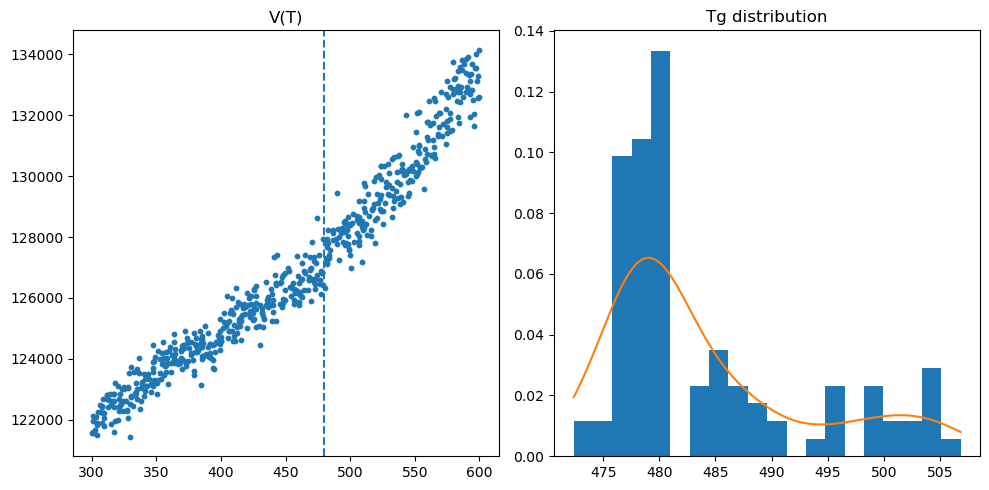

In [14]:
# MAIN
# ---------------------------------------

def main(file):

    T, V = load_lammps_log(file)
    T, V = preprocess(T,V)

    Tn, Vn, norm = normalize(T,V)

    mode, model = select_model(Tn,Vn)

    if mode=="piecewise":
        Tg_n = model[0]
        pred = pw_model(Tn,model)
    else:
        Tg_n = estimate_tg_spline(model,Tn)
        pred = model(Tn)

    Tg = denorm_T(Tg_n, norm)

    Tg_samples_n = bootstrap(Tn,Vn,mode)
    Tg_samples = denorm_T(Tg_samples_n, norm)

    mean, std = np.mean(Tg_samples), np.std(Tg_samples)

    alpha = alpha_first_150K(T, V)

    print("\nCLTE (0-100 K):")
    print(f"α = {alpha:.6e} K⁻¹")
    
    #Crystallic CLTE
    
    alpha_effective, alpha_amorphous = alpha_with_boyer_rule(T, V, X_c=0.35)

    print("\nCrystalline CLTE:")
    print(f"α = {alpha_effective:.6e} K⁻¹")
    
    # Detection Tg
    no_tg, slope_std, slope_var = detect_no_tg(T, V, Tg_samples)

    print("\n"+"="*50)
    print("Result")
    print("="*50)

    if no_tg:
        print("Tg is not defined")
        print(f"Reasons:")
        print(f"- significant variation of Tg (std = {std:.2f})")
        print(f"- slight change of inclination (std(dV/dT) = {slope_var:.4f})")
    else:
        print(f"Model: {mode}")
        print(f"Tg = {Tg:.2f} K")
        print(f"Tg = {mean:.2f} ± {std:.2f} K")
        
        
    # Graph
    kde = gaussian_kde(Tg_samples)
    x = np.linspace(min(Tg_samples), max(Tg_samples), 500)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.scatter(T,V,s=10)
    plt.axvline(Tg,ls='--')
    plt.title("V(T)")

    plt.subplot(1,2,2)
    plt.hist(Tg_samples, bins=20, density=True)
    plt.plot(x, kde(x))
    plt.title("Tg distribution")
    
    plt.tight_layout()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main('../LAMMPS/log.lammps')

Calculated Tg (МД): 479.41 K
Magnitude of Temperature Shift WLF: 61.41 K
Corrected Experimental Tg: 418.00 K (144.85 °C)


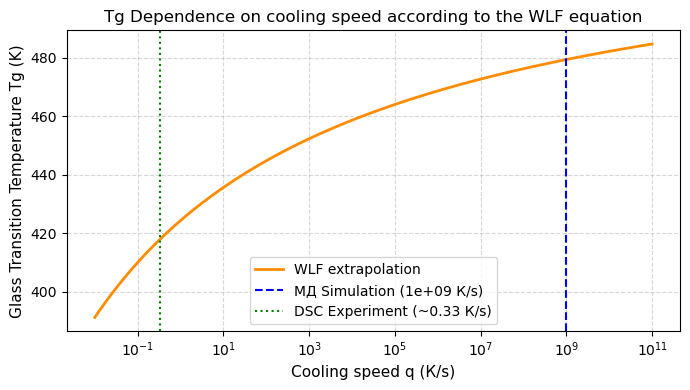

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Initial Data of Experiment
Tg_MD = 479.41      #  Tg (К) from the graph of a piecewise-linear approximation
q_MD = 1e9          # speed of cooling in MD (K/s)
q_exp = 20 / 60      # Experimental speed of DSC (20 K/min -> 0.333 K/s)

# Константы WLF (universal parameters Williams-Landel-Ferry)
C1 = 17.44
C2 = 51.6

# 1. Logarithm of the Speed Ratio
L = np.log10(q_exp / q_MD)

# 2. Temperature Shift Calculation
delta_T = (-C2 * L) / (C1 + L)

# 3. Location of real (experimental) Tg
Tg_corrected = Tg_MD - delta_T

print(f"Calculated Tg (МД): {Tg_MD:.2f} K")
print(f"Magnitude of Temperature Shift WLF: {delta_T:.2f} K")
print(f"Corrected Experimental Tg: {Tg_corrected:.2f} K ({Tg_corrected - 273.15:.2f} °C)")

# --- Visualization of Tg dependence on cooling speed ---
rates = np.logspace(-2, 11, 100) # speed range from 1 to 10^11 К/s
L_array = np.logspace(np.log10(q_exp), np.log10(1e11), 100)
L_log = np.log10(rates / q_MD)
Tg_profile = Tg_MD - (-C2 * L_log) / (C1 + L_log)

plt.figure(figsize=(7, 4), dpi=100)
plt.plot(rates, Tg_profile, label='WLF extrapolation', color='darkorange', lw=2)
plt.axvline(x=q_MD, color='blue', linestyle='--', label=f'МД Simulation ({q_MD:.0e} К/s)')
plt.axvline(x=q_exp, color='green', linestyle=':', label='DSC Experiment (~0.33 К/s)')
plt.xscale('log')
plt.xlabel('Cooling speed q (К/s)', fontsize=11)
plt.ylabel('Glass Transition Temperature Tg (K)', fontsize=11)
plt.title('Tg Dependence on cooling speed according to the WLF equation', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Mask-Based Preprocess 
# ---------------------------------------

def preprocess(T, V, min_T=600, max_T=800, step=2):
    mask = (T >= min_T) & (T <= max_T)
    T, V = T[mask], V[mask]

    idx = np.argsort(T)
    T, V = T[idx], V[idx]

    T = T[::step]
    V = V[::step]

    return T, V


Comparison of models:
----------------------------------------
Piecewise: RMSE=0.3838, CV=0.3486, AIC=-396.10
Spline   : RMSE=0.3830, CV=0.4789, AIC=-401.00

Result
Model: piecewise
Tm = 692.42 K
Tm = 694.10 ± 4.00 K


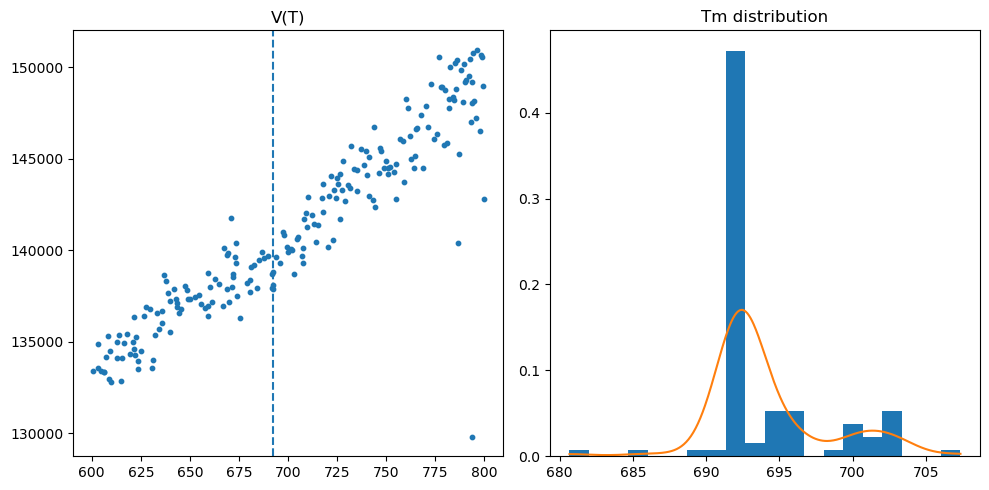

In [17]:
# MAIN
# ---------------------------------------

def main(file):

    T, V = load_lammps_log(file)
    T, V = preprocess(T,V)

    Tn, Vn, norm = normalize(T,V)

    mode, model = select_model(Tn,Vn)

    if mode=="piecewise":
        Tg_n = model[0]
        pred = pw_model(Tn,model)
    else:
        Tg_n = estimate_tg_spline(model,Tn)
        pred = model(Tn)

    Tg = denorm_T(Tg_n, norm)

    Tg_samples_n = bootstrap(Tn,Vn,mode)
    Tg_samples = denorm_T(Tg_samples_n, norm)

    mean, std = np.mean(Tg_samples), np.std(Tg_samples)

        # Detection Tm
    no_tg, slope_std, slope_var = detect_no_tg(T, V, Tg_samples)

    print("\n"+"="*50)
    print("Result")
    print("="*50)

    if no_tg:
        print("Tm is not defined")
        print(f"Reasons:")
        print(f"- significant variation of Tm (std = {std:.2f})")
        print(f"- slight change of inclination (std(dV/dT) = {slope_var:.4f})")
    else:
        print(f"Model: {mode}")
        print(f"Tm = {Tg:.2f} K")
        print(f"Tm = {mean:.2f} ± {std:.2f} K")
        
        
    # График
    kde = gaussian_kde(Tg_samples)
    x = np.linspace(min(Tg_samples), max(Tg_samples), 500)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.scatter(T,V,s=10)
    plt.axvline(Tg,ls='--')
    plt.title("V(T)")

    plt.subplot(1,2,2)
    plt.hist(Tg_samples, bins=20, density=True)
    plt.plot(x, kde(x))
    plt.title("Tm distribution")
    
    plt.tight_layout()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main('../LAMMPS/log.lammps')

Calculated Tm (МД): 692.42 K
Magnitude of Temperature Shift WLF: 61.41 K
Corrected Experimental Tm: 631.01 K (357.86 °C)


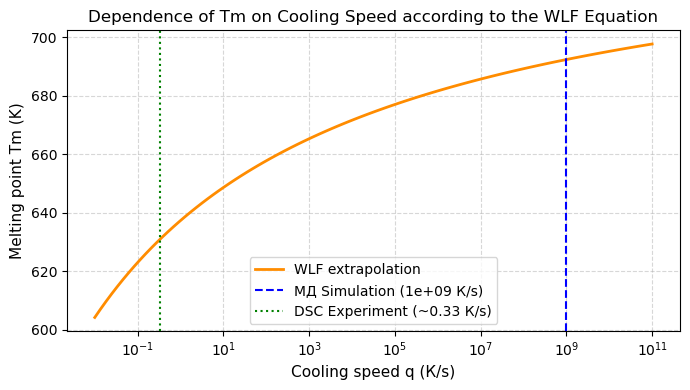

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Initial Data of Experiment
Tg_MD = 692.42      # Tm (К) from the graph of a piecewise-linear approximation
q_MD = 1e9          # speed of cooling in MD (K/s)
q_exp = 20 / 60      # Experimental speed of DSC (20 K/min -> 0.333 K/s)

# Константы WLF (universal parameters Williams-Landel-Ferry)
C1 = 17.44
C2 = 51.6

# 1. Logarithm of the Speed Ratio
L = np.log10(q_exp / q_MD)

# 2. Temperature Shift Calculation
delta_T = (-C2 * L) / (C1 + L)

# 3. Location of real (experimental) Tm
Tg_corrected = Tg_MD - delta_T

print(f"Calculated Tm (МД): {Tg_MD:.2f} K")
print(f"Magnitude of Temperature Shift WLF: {delta_T:.2f} K")
print(f"Corrected Experimental Tm: {Tg_corrected:.2f} K ({Tg_corrected - 273.15:.2f} °C)")

# --- Visualization of Tm dependence on cooling speed ---
rates = np.logspace(-2, 11, 100) # speed range from 1 to 10^11 К/s
L_array = np.logspace(np.log10(q_exp), np.log10(1e11), 100)
L_log = np.log10(rates / q_MD)
Tg_profile = Tg_MD - (-C2 * L_log) / (C1 + L_log)

plt.figure(figsize=(7, 4), dpi=100)
plt.plot(rates, Tg_profile, label='WLF extrapolation', color='darkorange', lw=2)
plt.axvline(x=q_MD, color='blue', linestyle='--', label=f'МД Simulation ({q_MD:.0e} К/s)')
plt.axvline(x=q_exp, color='green', linestyle=':', label='DSC Experiment (~0.33 К/s)')
plt.xscale('log')
plt.xlabel('Cooling speed q (К/s)', fontsize=11)
plt.ylabel('Melting point Tm (K)', fontsize=11)
plt.title('Dependence of Tm on Cooling Speed according to the WLF Equation', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()